#### **Time series - forecasting**

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
import pickle

#### **Carga de datos**

In [43]:
df = pd.read_csv('/workspaces/GuilloMansa-MachineLearning/data/raw/sales.csv')
df

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633
...,...,...
361,2023-08-30 17:10:08.079328,989.600354
362,2023-08-31 17:10:08.079328,994.987326
363,2023-09-01 17:10:08.079328,995.814415
364,2023-09-02 17:10:08.079328,997.350214


In [44]:
df.shape

(366, 2)

In [45]:
df.nunique(), df.duplicated().sum()

(date     366
 sales    366
 dtype: int64,
 np.int64(0))

#### **Construcción y analisis de serie temporal**

In [46]:
#pasamos date a formato fecha
df["date"] = pd.to_datetime(df["date"])

In [47]:
# dejamos date con indices
df = df.set_index("date")

In [48]:
# ponemos cronologicamente
df = df.sort_index()

In [49]:
df.head(5)

,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633


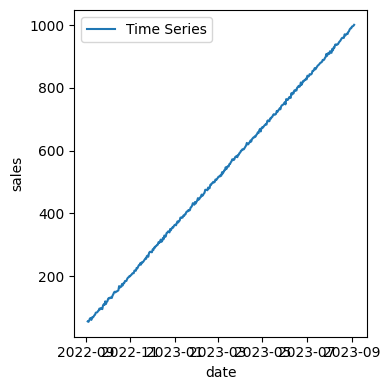

In [50]:
fig, axis = plt.subplots(figsize=(4, 4))
sns.lineplot(data=df["sales"], label="Time Series")

plt.tight_layout()
plt.show()

In [51]:
# lo hacemos de forma semanal y luego hacemos la tendencia y la estacional tambien. Comparación de graficos
decomposition = seasonal_decompose(df["sales"], period=7)

In [52]:
trend = decomposition.trend
seasonal = decomposition.seasonal

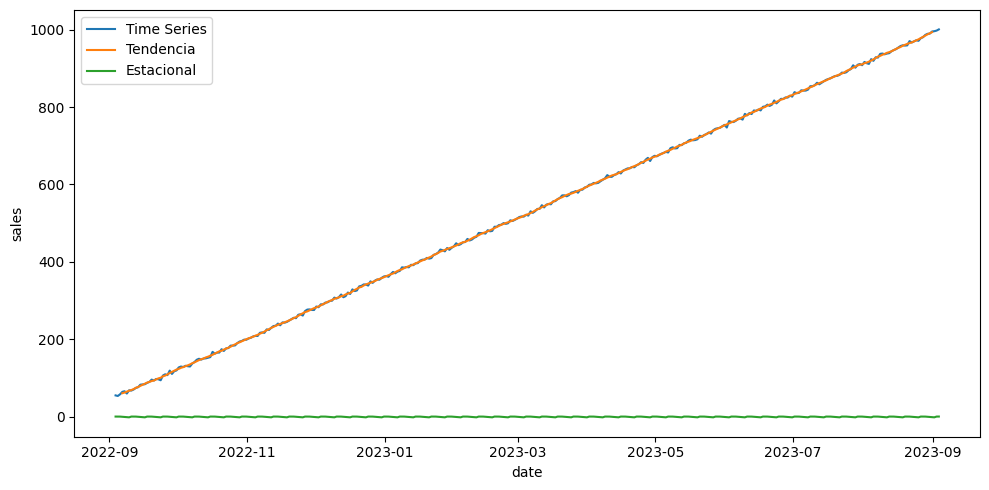

In [53]:
fig, axis = plt.subplots(figsize=(10, 5))
sns.lineplot(data=df["sales"], label="Time Series")
sns.lineplot(data=trend, label="Tendencia")
sns.lineplot(data=seasonal, label="Estacional")

plt.tight_layout()
plt.show()

#### **Observaciones:**
- Time series - linea azul: nos da los datos reales de las ventas dia a dia, casi que se superpone perfectamente con la linea naranja de tendencia.
- Seasonal - linea verde: esta linea casi constante plana nos indica que no hay variaciones ni patrones de comportamiento estacionales.
- Tendencia - linea naranja: se ve una tendencia creciente, esto indica que aumentan las ventas dia a dia.

#### **D-Fuller Test**

In [54]:
# Run ADF test
adf_result = adfuller(df["sales"])

In [61]:
#ponemos resultados en dict
results = {"ADF Statistic": adf_result[0], "p-value": adf_result[1], "Lags Used": adf_result[2], "Number of Observations": adf_result[3], "Critical Values": adf_result[4]}
results

{'ADF Statistic': np.float64(0.545414193706378),
 'p-value': np.float64(0.9861899815311064),
 'Lags Used': 13,
 'Number of Observations': 352,
 'Critical Values': {'1%': np.float64(-3.4490648539347544),
  '5%': np.float64(-2.8697861692116478),
  '10%': np.float64(-2.5711631253228306)}}

#### **ARIMA**

In [ ]:
model = auto_arima(df["sales"], seasonal=True, trace=True, m=7)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=1.45 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=2096.542, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=1966.396, Time=0.15 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=inf, Time=0.65 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=2209.657, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=1970.972, Time=0.04 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=1968.120, Time=0.34 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=1968.220, Time=0.22 sec
 ARIMA(1,1,0)(0,0,1)[7] intercept   : AIC=1966.919, Time=0.10 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=1965.376, Time=0.73 sec
 ARIMA(1,1,0)(2,0,2)[7] intercept   : AIC=1965.211, Time=0.77 sec
 ARIMA(1,1,0)(1,0,2)[7] intercept   : AIC=1963.937, Time=0.61 sec
 ARIMA(1,1,0)(0,0,2)[7] intercept   : AIC=1967.822, Time=0.22 sec
 ARIMA(0,1,0)(1,0,2)[7] intercept   : AIC=2094.918, Time=0.50 sec
 ARIMA(2,1,0)(1,0,2)[7] intercept   : AIC=1

In [58]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                  366
Model:             SARIMAX(4, 1, 1)x(0, 0, 1, 7)   Log Likelihood                -912.372
Date:                           Mon, 15 Dec 2025   AIC                           1840.744
Time:                                   11:44:23   BIC                           1871.943
Sample:                               09-03-2022   HQIC                          1853.143
                                    - 09-03-2023                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.8853      0.378      7.634      0.000       2.145       3.626
ar.L1         -0.0805      0.054     -1.500      0.134      -0.186       0.025
ar.L2          0.0168      0.063      0.269      0.788      -0.106       0.139
ar.L3          0.0242      0.058      0.414      0.679      -0.090       0.139
ar.L4         -0.0713      0.053     -1.351      0.177      -0.175       0.032
ma.L1         -0.9393      0.026    -36.334      0.000      -0.990      -0.889
ma.S.L7        0.1039      0.053      1.944      0.052      -0.001       0.209
sigma2         8.4131      0.658     12.789      0.000       7.124       9.702
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.95
Prob(Q):                              0.95   Prob(JB):                         0.62
Heteroskedasticity (H):               0.91   Skew:                             0.07
Prob(H) (two-sided):                  0.59   Kurtosis:                         2.79
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# prediccion 30 dias
forecast = model.predict(n_periods=30)

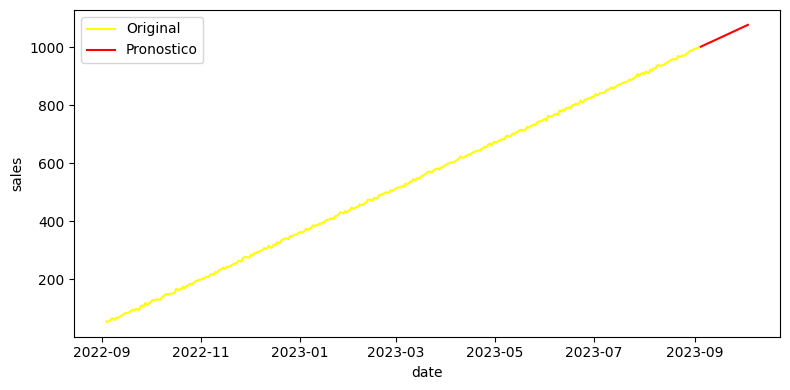

In [63]:
fig, axis = plt.subplots(figsize=(8, 4))
sns.lineplot(data=df['sales'], label='Original', color='yellow')
sns.lineplot(data=forecast, label='Pronostico', color='red')

plt.tight_layout()
plt.show()

#### **Observaciones**: se observa que las dos lineas son casi iguales, lo que se confirma una buena prediccion, y que el pronostico tiene una importante credibilidad y poder de acierto.

In [64]:
with open('/workspaces/GuilloMansa-MachineLearning/models/10-Time-series-forecasting.pkl', 'wb') as file:
    pickle.dump(model, file)